<a href="https://colab.research.google.com/github/akashg9705/colab_proj/blob/main/titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download(
    "shuofxz/titanic-machine-learning-from-disaster"
)

print("Dataset path:", path)
print(os.listdir(path))

Using Colab cache for faster access to the 'titanic-machine-learning-from-disaster' dataset.
Dataset path: /kaggle/input/titanic-machine-learning-from-disaster
['train.csv', 'test.csv', '.nfs0000000068ad779700000016']


LOAD


In [3]:
train_path = os.path.join(path, "train.csv")

df = pd.read_csv(train_path)

print(df.shape)
df.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
print(df.info())
print(df.isnull().sum())
print(df.describe())
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Drop Cabin because most values are missing
df.drop('Cabin', axis=1, inplace=True)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int6

/tmp/ipykernel_1763/3160022844.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_1763/3160022844.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

TRAIN TEST


In [5]:
from sklearn.model_selection import train_test_split

X = df.drop(
    ['Survived','PassengerId','Name','Ticket'],
    axis=1
)

y = df['Survived']

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

FEATURE Engineering


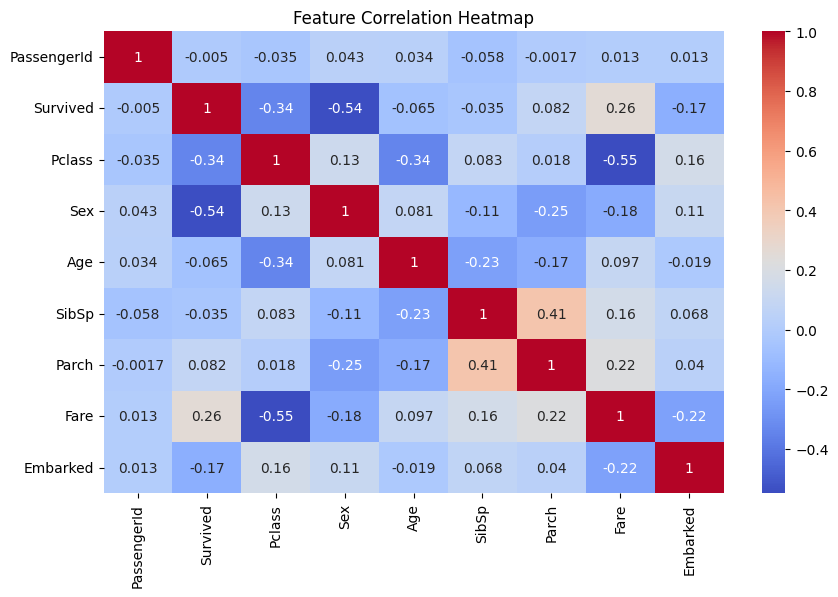

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Feature Correlation Heatmap")
plt.show()

In [7]:
from sklearn.ensemble import RandomForestClassifier

rf_temp = RandomForestClassifier(random_state=42)
rf_temp.fit(X_train,y_train)

importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf_temp.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

    Feature  Importance
1       Sex    0.271410
5      Fare    0.265010
2       Age    0.249995
0    Pclass    0.086957
3     SibSp    0.053685
4     Parch    0.039897
6  Embarked    0.033044


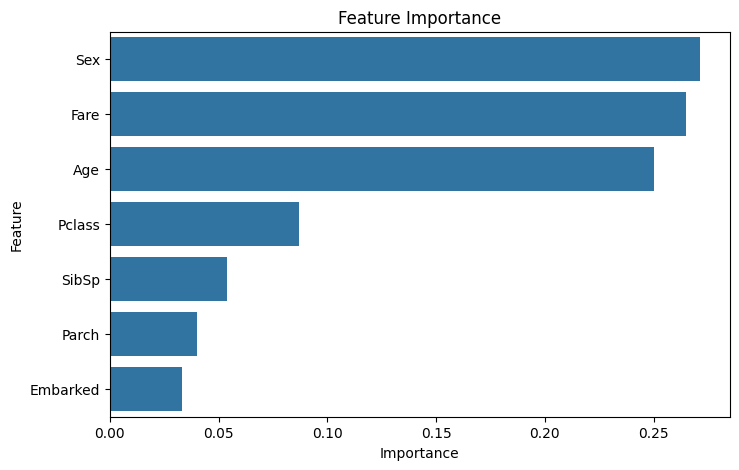

In [8]:
plt.figure(figsize=(8,5))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)
plt.title("Feature Importance")
plt.show()

MODELS

LOGISTIC


In [9]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

lr_pred = lr.predict(X_test)

RF

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

KNN

In [11]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train,y_train)

knn_pred = knn.predict(X_test)

EVALUATE

In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "KNN"
    ],
    "Accuracy":[
        accuracy_score(y_test,lr_pred),
        accuracy_score(y_test,rf_pred),
        accuracy_score(y_test,knn_pred)
    ],
    "Precision":[
        precision_score(y_test,lr_pred),
        precision_score(y_test,rf_pred),
        precision_score(y_test,knn_pred)
    ],
    "Recall":[
        recall_score(y_test,lr_pred),
        recall_score(y_test,rf_pred),
        recall_score(y_test,knn_pred)
    ],
    "F1 Score":[
        f1_score(y_test,lr_pred),
        f1_score(y_test,rf_pred),
        f1_score(y_test,knn_pred)
    ]
})

results.sort_values(
    by='F1 Score',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
1,Random Forest,0.821229,0.808824,0.743243,0.774648
0,Logistic Regression,0.810056,0.785714,0.743243,0.763889
2,KNN,0.703911,0.684211,0.527027,0.595420


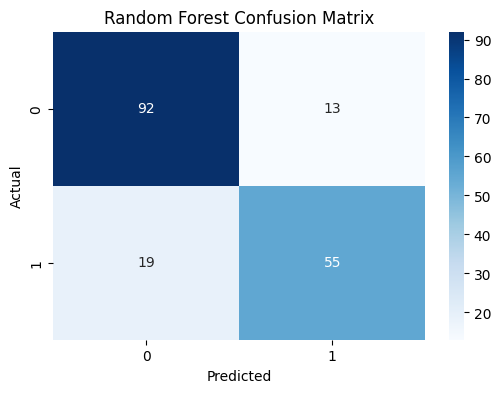

In [13]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,rf_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

1. Three classification models were trained to predict passenger survival.
2. Random Forest achieved the highest overall performance based on F1 Score and Accuracy.
3. Sex, Fare, Age and Passenger Class were the most influential features.
4. The confusion matrix showed that the model correctly classified most passengers.
5. Therefore, Random Forest was selected as the best model for this prediction task.